In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/HR_Analytics.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/HR_Analytics.csv'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

In [8]:
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [12]:
# Multi-class Categorical encoding (One-Hot Encoding)
base_attrition_rate = df_encoded['Attrition'].mean()
print(f"\nBaseline Attrition Rate: {base_attrition_rate:.2%}")


Baseline Attrition Rate: 16.12%


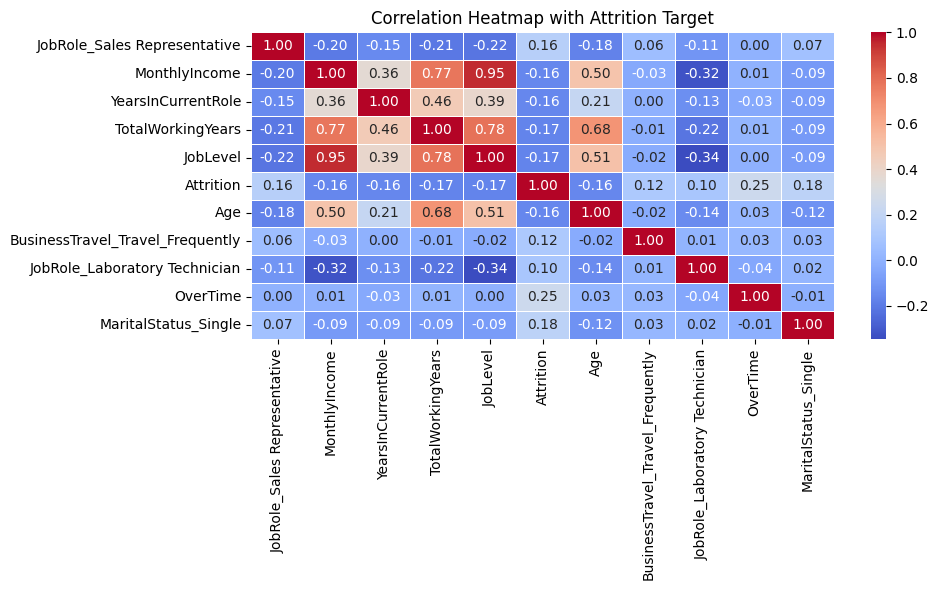

In [13]:
plt.figure(figsize=(10, 6))
top_corr = df_encoded.corr()['Attrition'].sort_values(ascending=False).head(6).index.tolist() + \
           df_encoded.corr()['Attrition'].sort_values(ascending=False).tail(5).index.tolist()
sns.heatmap(df_encoded[list(set(top_corr))].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap with Attrition Target")
plt.tight_layout()
plt.show()

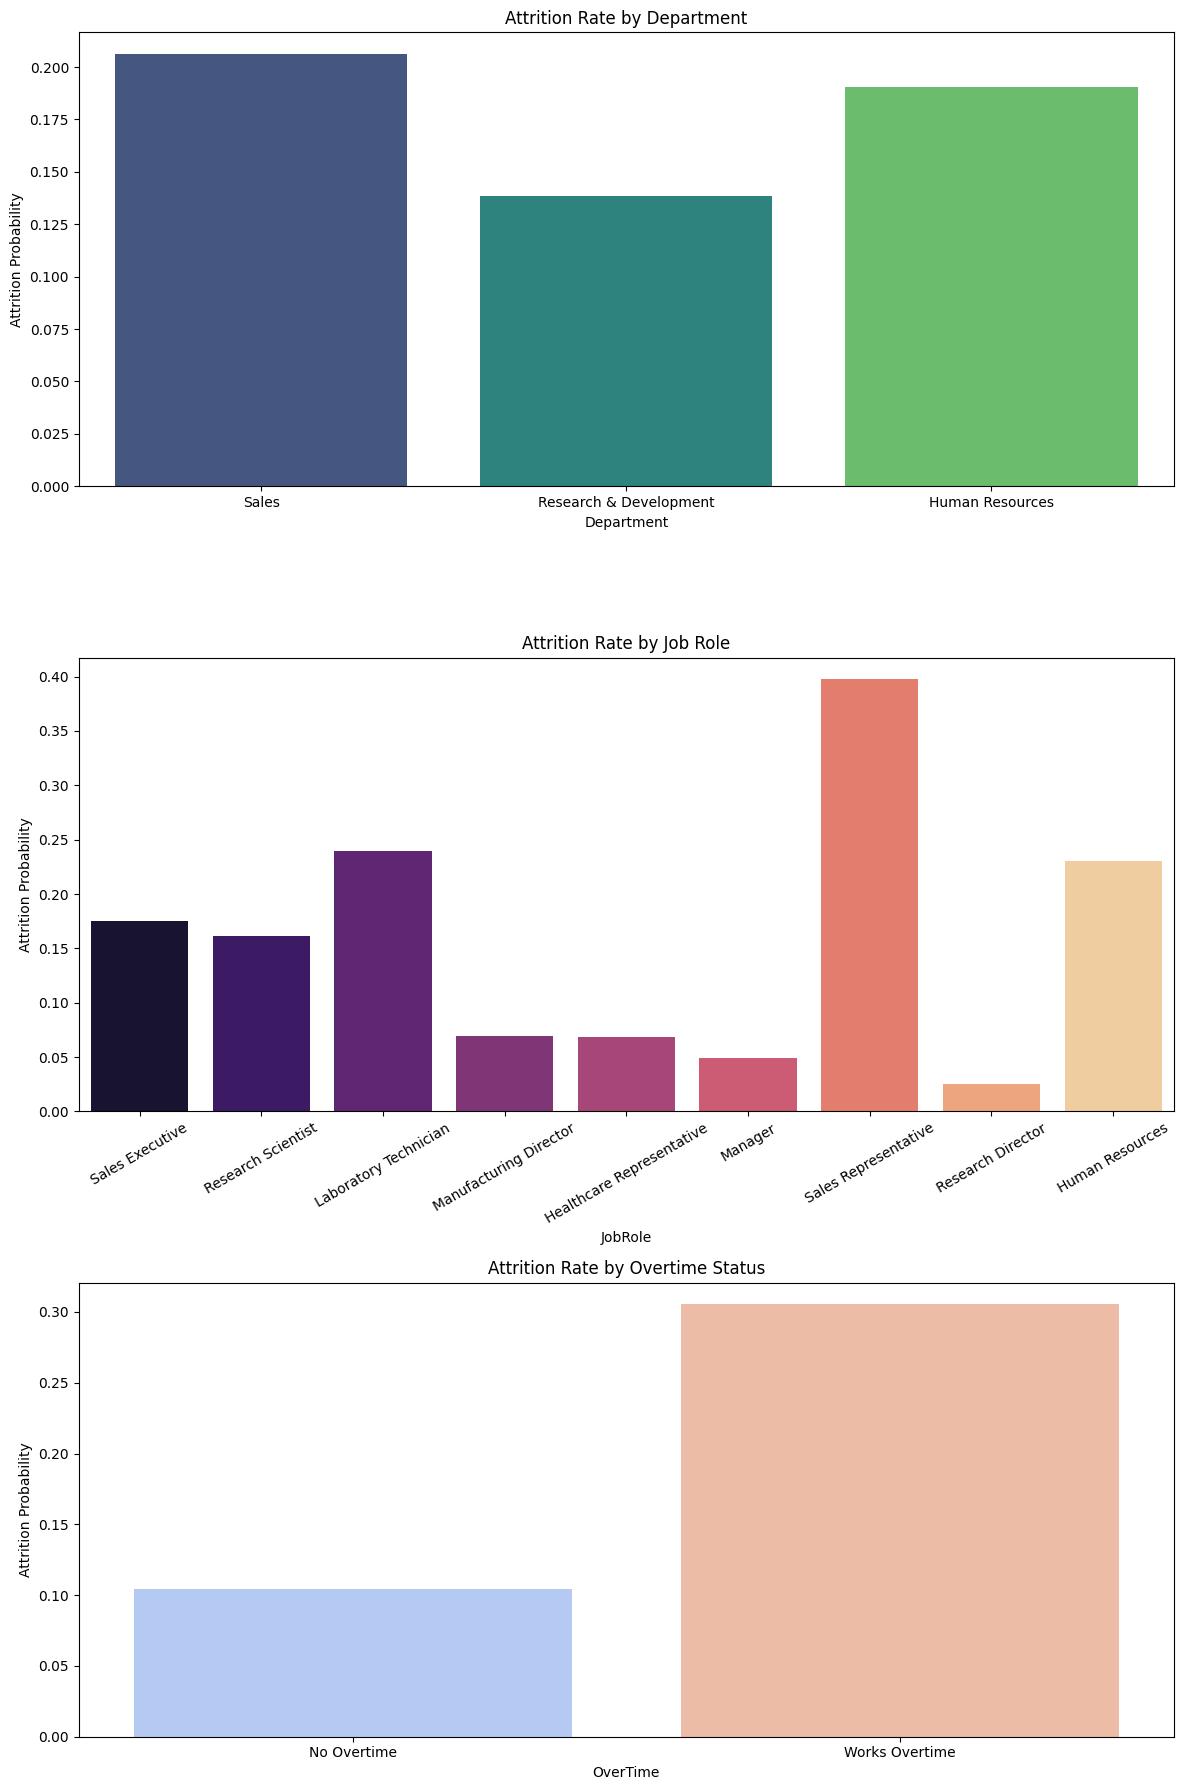

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Department
sns.barplot(
    ax=axes[0],
    x='Department',
    y='Attrition',
    data=df,
    errorbar=None,
    palette='viridis',
    hue='Department',
    legend=False
)
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Probability')

# 2. Job Role
sns.barplot(
    ax=axes[1],
    x='JobRole',
    y='Attrition',
    data=df,
    errorbar=None,
    palette='magma',
    hue='JobRole',
    legend=False
)
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_ylabel('Attrition Probability')
axes[1].tick_params(axis='x', rotation=30, labelbottom=True)

# 3. OverTime
sns.barplot(
    ax=axes[2],
    x='OverTime',
    y='Attrition',
    data=df,
    errorbar=None,
    palette='coolwarm',
    hue='OverTime',
    legend=False
)
axes[2].set_title('Attrition Rate by Overtime Status')
axes[2].set_ylabel('Attrition Probability')

axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['No Overtime', 'Works Overtime'])

plt.tight_layout()
plt.show()

In [21]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

In [24]:
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=10)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [32]:
y_pred=model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

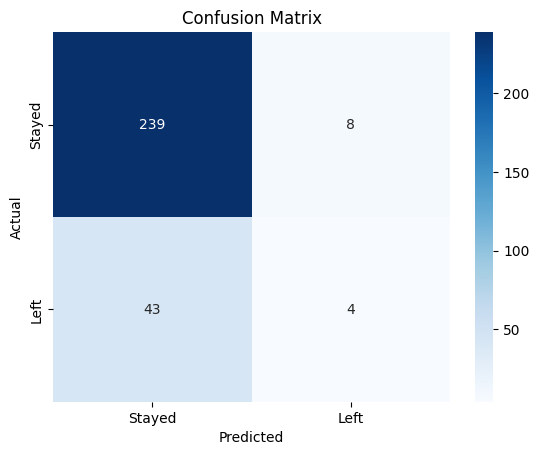

In [34]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
print("\n--- Imbalance-Aware Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))


--- Imbalance-Aware Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.90       247
        Left       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [36]:
# Extract Feature Importances
importances = model.feature_importances_
feature_names = X.columns
model_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

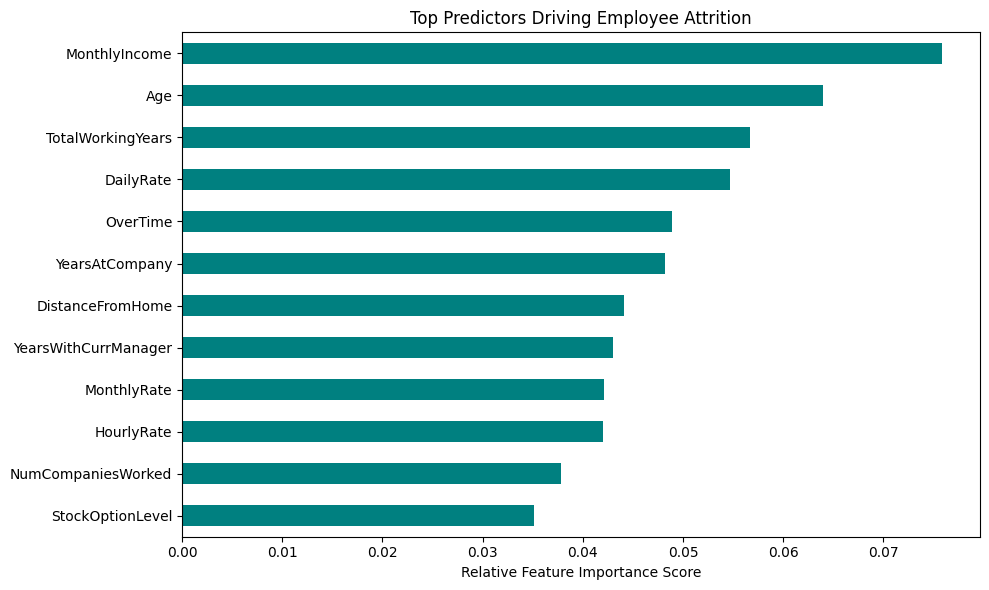

In [37]:
# Plot top 12 most impactful drivers
plt.figure(figsize=(10, 6))
model_importances.head(12).plot(kind='barh', color='teal').invert_yaxis()
plt.title("Top Predictors Driving Employee Attrition")
plt.xlabel("Relative Feature Importance Score")
plt.tight_layout()
plt.show()

In [38]:
print("\n--- Top 5 Predictive Features ---")
print(model_importances.head(5))


--- Top 5 Predictive Features ---
MonthlyIncome        0.075842
Age                  0.063962
TotalWorkingYears    0.056684
DailyRate            0.054689
OverTime             0.048912
dtype: float64
